## Welcome to the basic neural network tutorial!
The following notebook is designed to walk through the process of building and training your first scikit based algorithm using the standalone MaCh3 python utilities!

If you're writing scripts this is encapsulate in the objects in `MaCh3PythonUtils/config_reader` however this guide aims to break apart the process of writing the code for yourself!

The first step is to load in a MaCh3 MCMC fit as input file. This is done using the ChainHandler class!

In [2]:
# MaCh3Python Deps
from MaCh3PythonUtils.file_handling.chain_handler import ChainHandler
from MaCh3PythonUtils.machine_learning.ml_factory import MLFactory

# Other imports
from matplotlib import pyplot as plt
from pathlib import Path
import numpy as np
import random as rand
import os
import pandas as pd
import gdown

Using mps device

In [3]:


file_url="https://drive.google.com/file/d/1iE6xFhn3BH_HnLUfQ7KFGy2wfeH52Rwf/view?usp=sharing"


path_2= Path("../models/chain_files_2/")
path_4= Path('../models/chain_files_4/')
path_8= Path('../models/chain_files_8/')
path_16= Path('../models/chain_files_16/')

pathlist2=[f"{path_2}/{x}" for x in os.listdir(path_2)] 
pathlist4=[f'{path_4}/{y}' for y in os.listdir(path_4)]
pathlist8=[f'{path_8}/{z}' for z in os.listdir(path_8)]
pathlist16=[f'{path_16}/{a}' for a in os.listdir(path_16)]

paths = (pathlist2, pathlist4, pathlist8, pathlist16)

fitting_label = "ID"

# chain_list [for file in folder ChainHandler(input_file, chain_name, verbose=verbse)]
chain_list_2 = []
chain_list_4 = []
chain_list_8 = []
chain_list_16 = []

for lm in paths:
    for x in lm:
        chain_handler = ChainHandler(x, 'posteriors', verbose='verbose')
            
            # Process all the files
        chain_handler.ignore_plots(["xsec_20", "xsec_19"])
        chain_handler.add_additional_plots(["xsec_0", "xsec_1", "xsec_2", "xsec_3", "xsec_4", "xsec_5", "xsec_6", "xsec_7", "xsec_8", "xsec_9", "xsec_10", "xsec_11", "xsec_12", "xsec_13",
                                            "xsec_14", "xsec_15", "xsec_16", "xsec_17", "xsec_18", "xsec_21", "xsec_22"])
            #We need to make sure the chain handler knows this exists, passing true means it is looking for some with that exact name
            # chain_handler.add_additional_plots(fitting_label, True)

            # Finally we can do some cuts to get rid of things like burn-in
        chain_handler.add_new_cuts(["LogL<22.5", "step>10000", "delm2_23>0"])
        chain_handler.add_new_cuts(["step>0", "LogL_systematic_xsec_cov<12345"])

            # Last step is  convert the chain data files into a pandas dataframe
        y= chain_handler.convert_ttree_to_array()
        #chain_list_2.append(chain_handler)


        if lm == pathlist2:
            chain_list_2.append(chain_handler)
            print(chain_handler, '-> chain_list_2')
        elif lm == pathlist4:
            chain_list_4.append(chain_handler)
            print(chain_handler, '-> chain_list_4')
        elif lm == pathlist8:
            chain_list_8.append(chain_handler)
            print(chain_handler, '-> chain_list_8')
        elif lm == pathlist16:
            chain_list_16.append(chain_handler)
            print(chain_handler, '-> chain_list_16')
#on a random selection of parameters, change each value of that entire coloumn from a random float between 0 and 1
#this is done for the 2nd and 3rd index of the list, the first one unchanged on purpose. 
#want to iterate instead of choosing one param to change
"""
    
    chain_list[1].ttree_array[f'xsec_{i}']= np.round(np.random.random(size=len(chain_list[1].ttree_array)), 5)
    chain_list[2].ttree_array[f'xsec_{i}']= np.round(np.random.random(size=len(chain_list[2].ttree_array)),5)
    chain_list[3].ttree_array[f'xsec_{i}']= np.round(np.random.random(size=len(chain_list[3].ttree_array)), 5)
    chain_list[4].ttree_array[f'xsec_{i}']= np.round(np.random.random(size=len(chain_list[4].ttree_array)),5)
    chain_list[5].ttree_array[f'xsec_{i}']= np.round(np.random.random(size=len(chain_list[5].ttree_array)),5)
    

for i in range(24):  # i from 0 to 22
    for f in range(1, len(path_l[1:])):  # chain_list[1] to chain_list[5]
        chain_list[f].ttree_array[f'xsec_{i}'] = np.round(np.random.random(size=len(chain_list[f].ttree_array))*1.25, 5)
"""


main_chain2 = chain_list_2[0]
main_chain2.ttree_array['ID']= 0 #give the first file, containing chain data, the chain ID of 0

main_chain4 = chain_list_4[0]
main_chain4.ttree_array['ID']= 0

main_chain8 = chain_list_8[0]
main_chain8.ttree_array['ID']= 0

main_chain16 = chain_list_16[0]
main_chain16.ttree_array['ID']= 0


for id, chain in enumerate(chain_list_2[1:], start = 1): #iterate over the rest of the files and give it an acsending order Chain Ids starting from 1
    #add ID to chain['id']
    chain.ttree_array['ID'] = id
    chain.ttree_array[f'xsec_{rand.randint(0,20)}']= np.random.random(size=len(chain.ttree_array))
    main_chain2.ttree_array = pd.concat([main_chain2.ttree_array, chain.ttree_array])

for ida, chains in enumerate(chain_list_4[1:], start = 1): 
    #add ID to chain['id']
    chains.ttree_array['ID'] = ida
    chains.ttree_array[f'xsec_{rand.randint(0,20)}']= np.random.random(size=len(chains.ttree_array))
    main_chain4.ttree_array = pd.concat([main_chain4.ttree_array, chains.ttree_array])

for idb, chainss in enumerate(chain_list_8[1:], start = 1): 
    #add ID to chain['id']
    chainss.ttree_array['ID'] = idb
    chainss.ttree_array[f'xsec_{rand.randint(0,20)}']= np.random.random(size=len(chainss.ttree_array))
    main_chain8.ttree_array = pd.concat([main_chain8.ttree_array, chainss.ttree_array])

for idc, chainsss in enumerate(chain_list_16[1:], start = 1): 
    #add ID to chain['id']
    chainsss.ttree_array['ID'] = idc
    chainsss.ttree_array[f'xsec_{rand.randint(0,20)}']= np.random.random(size=len(chainsss.ttree_array))
    main_chain16.ttree_array = pd.concat([main_chain16.ttree_array, chainsss.ttree_array])






print(f'FINAL Framework: {main_chain2.ttree_array}')
'''
print(f'FINAL Framework: {main_chain4.ttree_array}')
print(f'FINAL Framework: {main_chain8.ttree_array}')
print(f'FINAL Framework: {main_chain16.ttree_array}')
'''




Attempting to open ../models/chain_files_2/demo_chain.root
Succesfully opened ../models/chain_files_2/demo_chain.root:posteriors
Using 12 threads and requiring 0.032 Gb memory
Using the following branches: 
  -> xsec_0
  -> xsec_1
  -> xsec_2
  -> xsec_3
  -> xsec_4
  -> xsec_5
  -> xsec_6
  -> xsec_7
  -> xsec_8
  -> xsec_9
  -> xsec_10
  -> xsec_11
  -> xsec_12
  -> xsec_13
  -> xsec_14
  -> xsec_15
  -> xsec_16
  -> xsec_17
  -> xsec_18
  -> xsec_21
  -> xsec_22
Converted TTree to pandas dataframe with 30304 elements
<MaCh3PythonUtils.file_handling.chain_handler.ChainHandler object at 0x30c549450> -> chain_list_2
Attempting to open ../models/chain_files_2/demo_chain2.root
Succesfully opened ../models/chain_files_2/demo_chain2.root:posteriors
Using 12 threads and requiring 0.032 Gb memory
Using the following branches: 
  -> xsec_0
  -> xsec_1
  -> xsec_2
  -> xsec_3
  -> xsec_4
  -> xsec_5
  -> xsec_6
  -> xsec_7
  -> xsec_8
  -> xsec_9
  -> xsec_10
  -> xsec_11
  -> xsec_12
  -> xse

"\nprint(f'FINAL Framework: {main_chain4.ttree_array}')\nprint(f'FINAL Framework: {main_chain8.ttree_array}')\nprint(f'FINAL Framework: {main_chain16.ttree_array}')\n"

## Machine learning
Okay now we've done some very basic file manipulation, it's time for some machine learning!
All algorithms use the same common `MLFactory` interface so let's go about configuring it!

In [4]:
# First step we need to initialise the factory
from pathlib import Path

model_output=Path("../models/chain_files_2/")
# Make sure the model output directory exists
model_output.parent.mkdir(parents=True, exist_ok=True)
print(fitting_label)
# The factory produces ML models, we need to pass it the chain handler and the fitting label to get started
ml_factory2 = MLFactory(main_chain2, fitting_label, f"{model_output}.pdf")


model_output=Path("../models/chain_files_4/")
# Make sure the model output directory exists
model_output.parent.mkdir(parents=True, exist_ok=True)
print(fitting_label)
# The factory produces ML models, we need to pass it the chain handler and the fitting label to get started
ml_factory4 = MLFactory(main_chain4, fitting_label, f"{model_output}.pdf")



model_output=Path("../models/chain_files_8/")
# Make sure the model output directory exists
model_output.parent.mkdir(parents=True, exist_ok=True)
print(fitting_label)
# The factory produces ML models, we need to pass it the chain handler and the fitting label to get started
ml_factory8 = MLFactory(main_chain8, fitting_label, f"{model_output}.pdf")


model_output=Path("../models/chain_files_16/")
# Make sure the model output directory exists
model_output.parent.mkdir(parents=True, exist_ok=True)
print(fitting_label)
# The factory produces ML models, we need to pass it the chain handler and the fitting label to get started
ml_factory16 = MLFactory(main_chain16, fitting_label, f"{model_output}.pdf")



ID
ID
ID
ID


Now we need to define a model, for this demonstration we'll make a very simple BDT!

In [5]:
# Now we can make the model
ml_model2 = ml_factory2.make_interface('SciKit', 'histboostclass', loss='log_loss', max_iter=20000, verbose=1, max_leaf_nodes=250)
ml_model2.set_training_test_set(0.2)

ml_model4 = ml_factory4.make_interface('SciKit', 'histboostclass', loss='log_loss', max_iter=20000, verbose=1, max_leaf_nodes=250)
ml_model4.set_training_test_set(0.2)
'''
ml_model8 = ml_factory8.make_interface('SciKit', 'histboostclass', loss='log_loss', max_iter=20000, verbose=1, max_leaf_nodes=250)
ml_model8.set_training_test_set(0.2)

ml_model16 = ml_factory16.make_interface('SciKit', 'histboostclass', loss='log_loss', max_iter=20000, verbose=1, max_leaf_nodes=250)
ml_model16.set_training_test_set(0.2)

'''

"\nml_model8 = ml_factory8.make_interface('SciKit', 'histboostclass', loss='log_loss', max_iter=20000, verbose=1, max_leaf_nodes=250)\nml_model8.set_training_test_set(0.2)\n\nml_model16 = ml_factory16.make_interface('SciKit', 'histboostclass', loss='log_loss', max_iter=20000, verbose=1, max_leaf_nodes=250)\nml_model16.set_training_test_set(0.2)\n\n"

In [6]:
# Now we need to train our network
ml_model2.train_model()

ml_model4.train_model()
'''
ml_model8.train_model()
ml_model16.train_model()
'''

Training Model
Binning 0.007 GB of training data: 0.057 s
Binning 0.001 GB of validation data: 0.003 s
Fitting gradient boosted rounds:
Fit 72 trees in 3.924 s, (18000 total leaves)
Time spent computing histograms: 1.464s
Time spent finding best splits:  0.828s
Time spent applying splits:      1.188s
Time spent predicting:           0.009s
Training Model
Binning 0.015 GB of training data: 0.065 s
Binning 0.002 GB of validation data: 0.003 s
Fitting gradient boosted rounds:
Fit 312 trees in 20.536 s, (77760 total leaves)
Time spent computing histograms: 8.105s
Time spent finding best splits:  4.801s
Time spent applying splits:      5.916s
Time spent predicting:           0.063s


'\nml_model8.train_model()\nml_model16.train_model()\n'

Number of independent MCMCs: 2

Training Results!

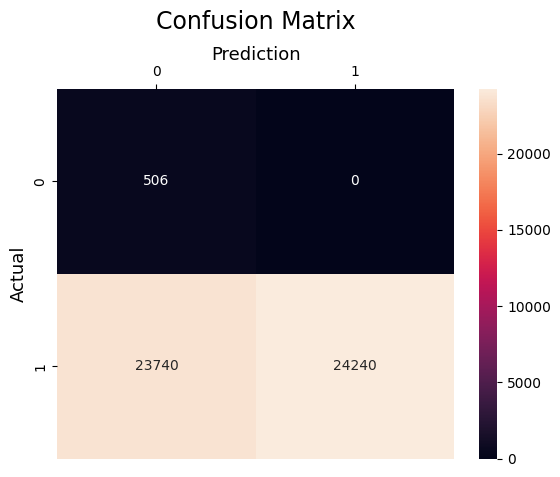

[[  506     0]
 [23740 24240]]

predictive accuracy: 0.5103741286144454

R*: 1.0207482572288908

=====

Testing Results!

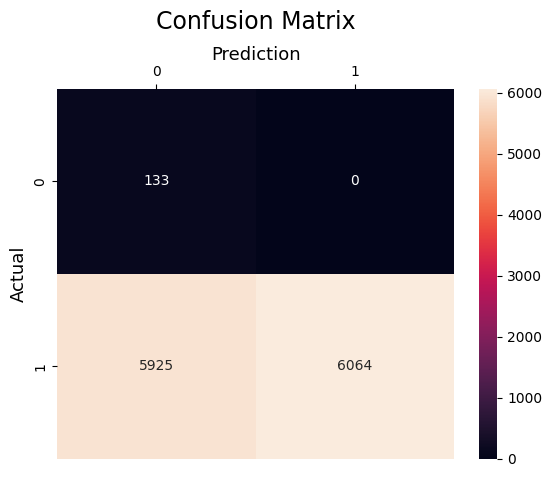

[[ 133    0]
 [5925 6064]]

predictive accuracy: 0.5112192707474014

R*: 1.0224385414948027

=====

Training Model

...

=====

[1.0217785843920144, 1.0224385414948027, 1.0201286916350438, 1.0176538524995875, 1.0221085629434086]

[]

Number of independent MCMCs: 4

Training Results!

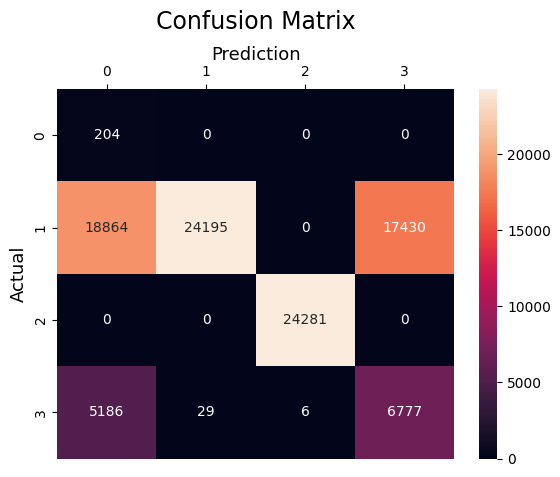

[[  204     0     0     0]
 [18864 24195     0 17430]
 [    0     0 24281     0]
 [ 5186    29     6  6777]]

predictive accuracy: 0.571886730190158

R*: 2.287546920760632

=====

Testing Results!

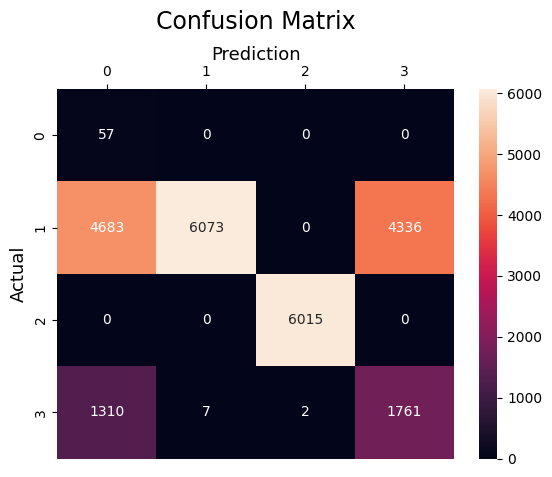

[[  57    0    0    0]
 [4683 6073    0 4336]
 [   0    0 6015    0]
 [1310    7    2 1761]]

predictive accuracy: 0.5735852169608976

R*: 2.2943408678435904

=====

Training Model

...

Testing Results!

=====

[]

[2.3299785513941593, 2.281471704339218, 2.304075235109718, 2.3042402243854148, 2.3007754495957764]

'\n# Now we need to test\nml_model8.test_model_class(chain_list_8)\n#outputs 2 confusion matrices; one for the training data and one f\nml_model8.getRStar_vals(chain_list_8)\n\n# Now we need to test\nml_model16.test_model_class(chain_list_16)\n#outputs 2 confusion matrices; one for the training data and one f\nml_model16.getRSTar2(chain_list_16)\n\n\n'

In [ ]:

ml_model2.test_model_class(chain_list_2)
ml_model2.getRStar_vals(chain_list_2)# gets an array of R* values

ml_model4.test_model_class(chain_list_4)
ml_model4.getRStar_vals(chain_list_4)





'''
# Now we need to test
ml_model8.test_model_class(chain_list_8)
#outputs 2 confusion matrices; one for the training data and one f
ml_model8.getRStar_vals(chain_list_8)

# Now we need to test
ml_model16.test_model_class(chain_list_16)
#outputs 2 confusion matrices; one for the training data and one f
ml_model16.getRSTar2(chain_list_16)


'''